In [1]:
import geopandas as gpd
import xarray as xr
from pyproj import Transformer
import xvec

In [31]:
gmw_zarr_path = "../../datasets/global-mangrove-watch-annual-extent/out/gmw-v4019-1km-mollweide.zarr"
abs_asgs_ste_path = "../../geometries/abs-asgs-edition-3/out/asgs-ste-2021.parquet"

# Do zonal statistics across all states

First we read in geoparquet containing the state boundaries, then we use the zarr data to calculate the zonal statistics for each state

In [30]:
gmw = xr.open_zarr(gmw_zarr_path)

gmw

<xarray.Dataset> Size: 3GB
Dimensions:        (y: 8901, band: 1, x: 35537)
Coordinates:
  * y              (y) float64 71kB 4.223e+06 4.222e+06 ... -4.677e+06
  * band           (band) int64 8B 1
  * x              (x) float64 284kB -1.76e+07 -1.76e+07 ... 1.793e+07 1.793e+07
Data variables:
    spatial_ref    int64 8B ...
    data_variable  (band, y, x) float64 3GB dask.array<chunksize=(1, 557, 2222), meta=np.ndarray>

In [ ]:
# Read in ASGS STE
asgs_ste_gdf = gpd.read_parquet(abs_asgs_ste_path)

# Filter out rows without geoms
asgs_ste_gdf = asgs_ste_gdf[asgs_ste_gdf.geometry.notnull()]

asgs_ste_gdf

,STE_CODE21,STE_NAME21,CHG_FLAG21,CHG_LBL21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,1,New South Wales,0,No change,AUS,Australia,8.007977e+05,http://linked.data.gov.au/dataset/asgsed3/STE/1,"MULTIPOLYGON (((159.0623 -31.50886, 159.06218 ..."
1,2,Victoria,0,No change,AUS,Australia,2.274962e+05,http://linked.data.gov.au/dataset/asgsed3/STE/2,"MULTIPOLYGON (((146.29286 -39.15778, 146.29341..."
2,3,Queensland,0,No change,AUS,Australia,1.730171e+06,http://linked.data.gov.au/dataset/asgsed3/STE/3,"MULTIPOLYGON (((142.5314 -10.68301, 142.53072 ..."
3,4,South Australia,0,No change,AUS,Australia,9.842314e+05,http://linked.data.gov.au/dataset/asgsed3/STE/4,"MULTIPOLYGON (((140.66025 -38.06256, 140.66006..."
4,5,Western Australia,0,No change,AUS,Australia,2.526632e+06,http://linked.data.gov.au/dataset/asgsed3/STE/5,"MULTIPOLYGON (((117.86953 -35.19108, 117.86961..."
5,6,Tasmania,0,No change,AUS,Australia,6.801754e+04,http://linked.data.gov.au/dataset/asgsed3/STE/6,"MULTIPOLYGON (((144.60439 -41.01001, 144.60443..."
6,7,Northern Territory,0,No change,AUS,Australia,1.348134e+06,http://linked.data.gov.au/dataset/asgsed3/STE/7,"MULTIPOLYGON (((133.02818 -10.90839, 133.02982..."
7,8,Australian Capital Territory,0,No change,AUS,Australia,2.358133e+03,http://linked.data.gov.au/dataset/asgsed3/STE/8,"POLYGON ((149.06239 -35.1591, 149.09134 -35.14..."
8,9,Other Territories,0,No change,AUS,Australia,2.557420e+02,http://linked.data.gov.au/dataset/asgsed3/STE/9,"MULTIPOLYGON (((167.94747 -29.12757, 167.94748..."


# Inspect chunks of zarr

This allows easy parallelisation of compute - we are just using GDALs default chunking here

In [7]:
# Look at chunks in zarr file

gmw.chunks

Frozen({'band': (1,), 'y': (557, 557, 557, 557, 557, 557, 557, 557, 557, 557, 557, 557, 557, 557, 557, 546), 'x': (2222, 2222, 2222, 2222, 2222, 2222, 2222, 2222, 2222, 2222, 2222, 2222, 2222, 2222, 2222, 2207)})

# Do zonal statistics across all states

We also crop data to extent of input geometries

In [22]:
# Crop gmw to asgs_ste_gdf bounds

asgs_ste_gdf_mol = asgs_ste_gdf.to_crs("+proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs")

gmw_within_regions = gmw["data_variable"].sel(x=slice(asgs_ste_gdf_mol.total_bounds[0], asgs_ste_gdf_mol.total_bounds[2]), y=slice(asgs_ste_gdf_mol.total_bounds[3], asgs_ste_gdf_mol.total_bounds[1]))

gmw_within_regions = gmw_within_regions.fillna(0)

In [23]:
gmw_within_regions

<xarray.DataArray 'data_variable' (band: 1, y: 3549, x: 5927)> Size: 168MB
dask.array<where, shape=(1, 3549, 5927), dtype=float64, chunksize=(1, 557, 2222), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 28kB -1.129e+06 -1.13e+06 ... -4.676e+06 -4.677e+06
  * band     (band) int64 8B 1
  * x        (x) float64 47kB 9.568e+06 9.569e+06 ... 1.549e+07 1.549e+07
Attributes:
    grid_mapping:  spatial_ref

## Calculate mean pixel

This will calculate the mean pixel value for each state, which represents the proportion of the state that is covered by mangroves (in units of 0.01 degree resolution pixels)

In [28]:
aggregated_mean = gmw_within_regions.xvec.zonal_stats(
    asgs_ste_gdf_mol.geometry,
    x_coords="x",
    y_coords="y",
    stats="mean",
    name="asgs_ste",
    index=True
).compute()

# Inspect results

We can look at the array of results directly

In [25]:
aggregated_mean

<xarray.DataArray 'data_variable' (asgs_ste: 9, band: 1)> Size: 72B
array([[1.20801675e-04],
       [6.58614013e-05],
       [2.08736926e-03],
       [8.90783829e-05],
       [6.90219266e-04],
       [           nan],
       [2.64174473e-03],
       [0.00000000e+00],
       [0.00000000e+00]])
Coordinates:
  * band      (band) int64 8B 1
  * asgs_ste  (asgs_ste) object 72B MULTIPOLYGON (((14441516.426549096 -38199...
    index     (asgs_ste) int64 72B 0 1 2 3 4 5 6 7 8
Indexes:
    asgs_ste  GeometryIndex (crs=+proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs + ...)
Attributes:
    grid_mapping:  spatial_ref

We can also pull out specific states

In [26]:
qld_mean = aggregated_mean.values[2]
qld_mean

array([0.00208737])

<Axes: >

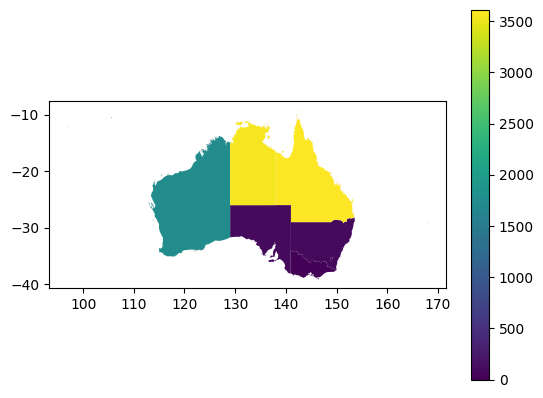

In [27]:
# Convert back to geodataframe - and merge in geometry values
gmw_mean = aggregated_mean.xvec.to_geodataframe()

gmw_mean = gmw_mean.merge(asgs_ste_gdf, left_on="index", right_index=True)

# Convert back to WGS84
gmw_mean = gmw_mean.to_crs("epsg:4326")

# Drop geometry column
gmw_mean = gmw_mean.drop(columns=["geometry"])

gmw_mean["mangrove_area"] = gmw_mean["AREASQKM21"] * gmw_mean["data_variable"]

gmw_mean.plot(column="mangrove_area", legend=True)